<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/LineCodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução à Transformada de Fourier

### Como representar um sinal periódico como sendo composto de uma série de Senos e Cossenos: Séries de Fourier

###<font color='pink'>Exemplo com uma onda quadrada </font>

For $t \in [0, 2\pi)$:

$$
\text{square_wave}(t) =
\begin{cases}
1, & 0 < t < \pi \\
0, & t = 0, \pi, 2\pi \\
-1, & \pi < t < 2\pi
\end{cases}
$$

E a série de Fourier que a representa é:

$$
f(t) = \frac{4}{\pi} \sum_{\substack{n=1 \\ n \text{ impar}}}^{\infty} \frac{\sin(nt)}{n}
$$

ou:

$$
f(t) = \frac{4}{\pi} \left( \sin(t) + \frac{1}{3}\sin(3t) + \frac{1}{5}\sin(5t) + \frac{1}{7}\sin(7t) + \cdots \right)
$$

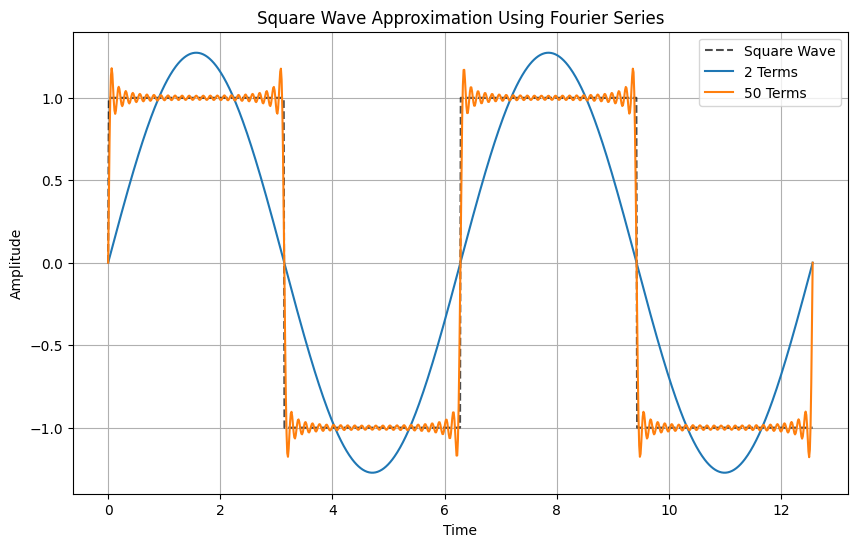

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the time values (e.g., from 0 to 4*pi with 1000 points)
t = np.linspace(0, 4 * np.pi, 1000)

# Define the square wave
square_wave = np.sign(np.sin(t))

# Fourier Series approximation function
def fourier_series_approximation(t, num_terms):
    result = np.zeros_like(t)
    for n in range(1, num_terms + 1, 2):  # Only odd harmonics
        result += (4 / (np.pi * n)) * np.sin(n * t)
    return result

# Plot the square wave and its Fourier Series approximations
plt.figure(figsize=(10, 6))

# Plot the actual square wave
plt.plot(t, square_wave, label='Square Wave', color='black', linestyle='--', alpha=0.7)

# Plot Fourier series approximations with different numbers of terms
#terms_to_plot = [1, 3, 5, 9, 15]
terms_to_plot = [2, 50]
for terms in terms_to_plot:
    approximation = fourier_series_approximation(t, terms)
    plt.plot(t, approximation, label=f'{terms} Terms')

# Customize the plot
plt.title('Square Wave Approximation Using Fourier Series')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


###<font color='pink'>Exemplo com uma onda Dente de serra (Sawtooth):</font>



A função da dente de serra utilizada é:


$$
\text{sawtooth_wave} = \left(\frac{1}{\pi}\right) \cdot (t \bmod \pi)
$$

E a série de Fourier que a representa é:

$$
f(t) = -\frac{1}{\pi} \sum_{n=1}^{\infty} \frac{\sin(2nt)}{n}
$$
ou:

$$
f(t) = -\frac{1}{\pi} \sin(2t) - \frac{1}{2\pi} \sin(4t) - \frac{1}{3\pi} \sin(6t) - \cdots
$$

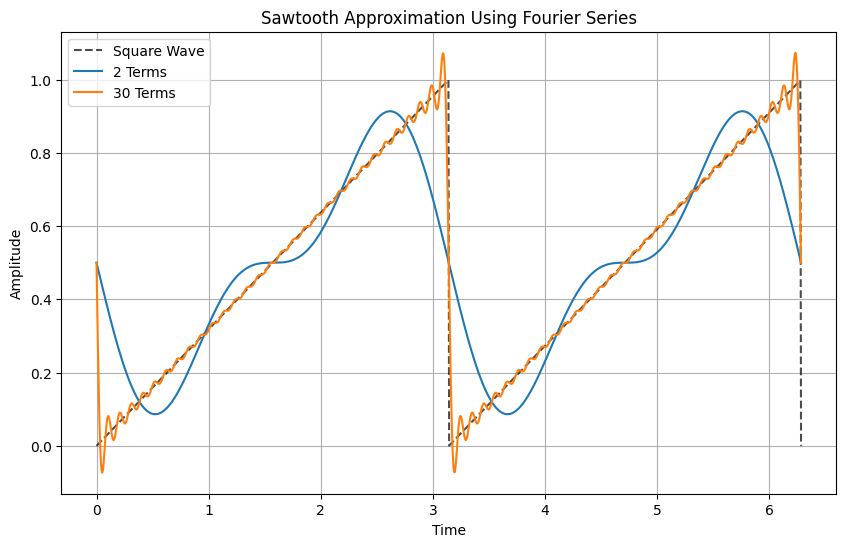

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the time values (e.g., from 0 to 2*pi with 1000 points)
t = np.linspace(0, 2 * np.pi, 1000)

# Define the sawtooth wave
sawtooth_wave = (1 / np.pi) * (t % np.pi)      # Two cycles within 0 to 2*pi

# Fourier Series approximation function
def  fourier_series_approximation_sawtooth(t, num_terms):
    result = 1/2
    for n in range(1, num_terms + 1):
        result -= (1 / (n * np.pi)) * ( np.sin(2 * n * t))  # Proper sine coefficients for 0 to 1 amplitude
    return result

# Plot the square wave and its Fourier Series approximations
plt.figure(figsize=(10, 6))

# Plot the actual square wave
plt.plot(t, sawtooth_wave, label='Square Wave', color='black', linestyle='--', alpha=0.7)

# Plot Fourier series approximations with different numbers of terms
#terms_to_plot = [1, 3, 5, 9, 15]
terms_to_plot = [2, 30]
for terms in terms_to_plot:
    approximation = fourier_series_approximation_sawtooth(t, terms)
    plt.plot(t, approximation, label=f'{terms} Terms')

# Customize the plot
plt.title('Sawtooth Approximation Using Fourier Series')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()